# 2. Data Preparation & Processing

Extract frames from videos, run a **pretrained YOLOv8** model to get initial person detections, define the **closest-person** heuristic, and export a clean YOLO-format dataset ready for fine-tuning.

### Closest-person definition
In a 2-D camera view the closest person has the **largest bounding-box area** (they occupy more pixels).  
We label that detection as the target during fine-tuning.

In [48]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'tqdm', 'matplotlib', 'pandas', 'pyyaml']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [49]:
import cv2
import os
import shutil
import yaml
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT           = Path('..').resolve()
DATA_DIR       = ROOT / 'data'
CORRECT_DIR    = DATA_DIR / 'correct_form'
WRONG_DIR      = DATA_DIR / 'wrong_form'

PD_DIR         = ROOT / 'person_detector'
FRAMES_DIR     = PD_DIR / 'data' / 'frames'        # raw extracted frames
DATASET_DIR    = PD_DIR / 'data' / 'dataset'       # YOLO-formatted dataset

# Dataset splits
for split in ['train', 'val', 'test']:
    for sub in ['images', 'labels']:
        (DATASET_DIR / split / sub).mkdir(parents=True, exist_ok=True)

(FRAMES_DIR).mkdir(parents=True, exist_ok=True)

print('FRAMES_DIR :', FRAMES_DIR)
print('DATASET_DIR:', DATASET_DIR)

# Reproducibility
random.seed(42)
np.random.seed(42)

FRAMES_DIR : /Users/haleytran/Downloads/pushup_judge/person_detector/data/frames
DATASET_DIR: /Users/haleytran/Downloads/pushup_judge/person_detector/data/dataset


## 2.1 Frame Extraction

In [50]:
# ── Config ────────────────────────────────────────────────────────────────────
SAMPLE_FPS   = 3     # frames-per-second to extract (keeps dataset manageable)
MAX_PER_VIDEO = 30   # hard cap per video

def extract_frames(video_path: Path, out_dir: Path,
                   sample_fps: int = SAMPLE_FPS,
                   max_frames: int = MAX_PER_VIDEO) -> list[Path]:
    """
    Extract frames evenly spaced at `sample_fps` from a video.
    Returns a list of saved frame paths.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    cap    = cv2.VideoCapture(str(video_path))
    src_fps  = cap.get(cv2.CAP_PROP_FPS) or 30
    total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    step     = max(1, int(src_fps / sample_fps))
    indices  = list(range(0, total, step))[:max_frames]

    stem   = video_path.stem.replace(' ', '_')
    saved  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        fname = out_dir / f'{stem}_f{idx:05d}.jpg'
        cv2.imwrite(str(fname), frame)
        saved.append(fname)

    cap.release()
    return saved


# Collect all videos
all_videos = [(p, 'correct') for p in sorted(CORRECT_DIR.glob('*.mp4'))] + \
             [(p, 'wrong')   for p in sorted(WRONG_DIR.glob('*.mp4'))]

print(f'Total videos: {len(all_videos)}')

video_frame_map = {}   # video_path → [frame_paths]

for vid_path, label in tqdm(all_videos, desc='Extracting frames'):
    out_dir = FRAMES_DIR / label / vid_path.stem.replace(' ', '_')
    frames  = extract_frames(vid_path, out_dir)
    video_frame_map[vid_path] = frames

total_frames = sum(len(v) for v in video_frame_map.values())
print(f'Total extracted frames: {total_frames:,}')

Total videos: 152


Extracting frames: 100%|██████████| 152/152 [00:31<00:00,  4.80it/s]

Total extracted frames: 1,858


## 2.2 Person Detection with Pretrained YOLOv8
Run YOLOv8n (fast, pretrained on COCO) to get initial person bounding boxes.

In [ ]:
GT_MODEL_NAME = 'yolo11m.pt'   # ← model used to generate ground-truth labels
DET_CACHE     = PD_DIR / 'data' / f'det_cache_{GT_MODEL_NAME.replace(".pt","")}.csv'

# Load a pretrained model (only when cache is missing)
PERSON_CLS  = 0      # COCO class 0 = person
CONF_THRESH = 0.70


def detect_persons(frame_path: Path, model: YOLO) -> tuple[list[dict], int, int]:
    """
    Run model on one frame.
    Returns (detections, frame_w, frame_h).
    Each detection: {x1, y1, x2, y2, conf, area, x_center, y_center, aspect_ratio}
    """
    img = cv2.imread(str(frame_path))
    frame_h, frame_w = img.shape[:2]
    results = model.predict(img, classes=[PERSON_CLS],
                            conf=CONF_THRESH, verbose=False)[0]
    detections = []
    if results.boxes is not None:
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            w_box = x2 - x1
            h_box = y2 - y1
            detections.append({
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'conf'         : float(box.conf[0]),
                'area'         : w_box * h_box,
                'x_center'     : (x1 + x2) / 2,
                'y_center'     : (y1 + y2) / 2,
                'aspect_ratio' : w_box / max(h_box, 1),  # >1 → wide/horizontal (prone)
            })
    return detections, frame_w, frame_h


def select_closest_person(detections: list[dict], frame_h: int, frame_w: int) -> dict | None:
    """
    Return the detection most likely to be the push-up performer.

    Score = area × (y_center / frame_h) × min(aspect_ratio, 2.0) × center_weight

    Rewards:
      • Large box              — person is physically close to camera
      • Low in the frame       — push-up performer is near the bottom
      • Wide/horizontal        — prone pose: width > height; standing bystander is the opposite
      • Horizontal centrality  — push-up subject is typically the focal point (centre of frame);
                                 bystanders crowd the edges.
                                 center_weight = 1 - |box_cx/frame_w - 0.5|  (1.0 = dead centre)
    """
    if not detections:
        return None
    return max(
        detections,
        key=lambda d: d['area']
                      * (d['y_center'] / frame_h)
                      * min(d['aspect_ratio'], 2.0)
                      * (1.0 - abs(d['x_center'] / frame_w - 0.5))
    )


def _load_det_cache() -> pd.DataFrame | None:
    if DET_CACHE.exists():
        print(f'[cache] Loading detection results from {DET_CACHE.name}')
        return pd.read_csv(DET_CACHE)
    return None


print(f'GT model    : {GT_MODEL_NAME}')
print(f'Cache path  : {DET_CACHE}')
if DET_CACHE.exists():
    print('[cache] Detection cache found — cell 8 will skip re-detection.')
else:
    pretrained = YOLO(GT_MODEL_NAME)   # download only when cache is absent
    print('Model loaded — will run detection in cell 8.')


GT model    : yolo11m.pt
Cache path  : /Users/haleytran/Downloads/pushup_judge/person_detector/data/det_cache_yolo11m.csv
Model loaded — will run detection in cell 8.


In [ ]:
det_df = _load_det_cache()

if det_df is None:
    # ── Collect all frame paths ───────────────────────────────────────────────
    all_frame_records = []
    for vid_path, frames in video_frame_map.items():
        label = 'correct' if 'correct_form' in str(vid_path) else 'wrong'
        for fp in frames:
            all_frame_records.append({'frame_path': fp, 'label': label})

    print(f'Total frames to process: {len(all_frame_records):,}')

    # ── Run detection ─────────────────────────────────────────────────────────
    detection_records = []
    for rec in tqdm(all_frame_records, desc=f'Detecting persons [{GT_MODEL_NAME}]'):
        fp                   = rec['frame_path']
        all_dets, fw, fh     = detect_persons(fp, pretrained)
        closest              = select_closest_person(all_dets, fh, fw)
        detection_records.append({
            'frame_path'   : str(fp),
            'label'        : rec['label'],
            'n_persons'    : len(all_dets),
            'has_closest'  : closest is not None,
            'closest_area' : closest['area']     if closest else 0,
            'closest_conf' : closest['conf']     if closest else 0,
            'closest_box'  : str([closest['x1'], closest['y1'],
                                   closest['x2'], closest['y2']]) if closest else None,
        })

    det_df = pd.DataFrame(detection_records)

    # ── Save cache ────────────────────────────────────────────────────────────
    DET_CACHE.parent.mkdir(parents=True, exist_ok=True)
    det_df.to_csv(DET_CACHE, index=False)
    print(f'Detection cache saved → {DET_CACHE}')
else:
    print(f'Skipped detection — loaded {len(det_df):,} rows from cache.')

print(f"Frames with at least 1 person: {det_df['has_closest'].sum()} / {len(det_df)}")
det_df.head()


Total frames to process: 1,858


Detecting persons [yolo11m.pt]: 100%|██████████| 1858/1858 [05:39<00:00,  5.47it/s]

Detection cache saved → /Users/haleytran/Downloads/pushup_judge/person_detector/data/det_cache_yolo11m.csv
Frames with at least 1 person: 1809 / 1858


,frame_path,label,n_persons,has_closest,closest_area,closest_conf,closest_box
0,/Users/haleytran/Downloads/pushup_judge/person...,correct,1,True,111686.123525,0.940643,"[14.621353149414062, 135.6246337890625, 523.60..."
1,/Users/haleytran/Downloads/pushup_judge/person...,correct,1,True,111464.845552,0.941293,"[7.50543212890625, 138.05703735351562, 521.375..."
2,/Users/haleytran/Downloads/pushup_judge/person...,correct,1,True,111743.667922,0.942184,"[3.51251220703125, 138.35179138183594, 519.352..."
3,/Users/haleytran/Downloads/pushup_judge/person...,correct,1,True,90797.615296,0.921787,"[3.64794921875, 181.4423370361328, 527.1447753..."
4,/Users/haleytran/Downloads/pushup_judge/person...,correct,1,True,72545.435923,0.906716,"[13.8536376953125, 215.38755798339844, 535.671..."


## 2.3 Visualise Closest-Person Detection

ValueError: invalid literal for int() with base 10: '['

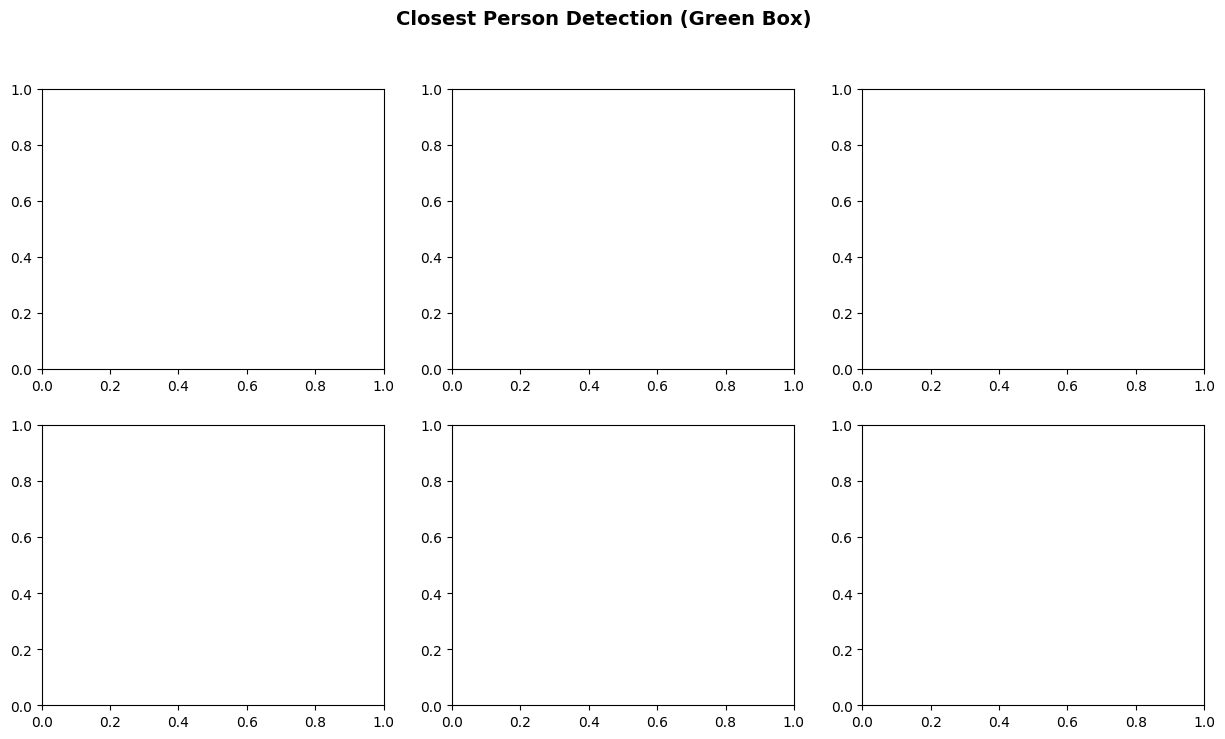

In [ ]:
import ast

def draw_closest_person(frame_path: str, box, conf: float) -> np.ndarray:
    img = cv2.cvtColor(cv2.imread(frame_path), cv2.COLOR_BGR2RGB)
    if isinstance(box, str):
        box = ast.literal_eval(box)   # CSV stores list as string
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(img, f'Closest {conf:.2f}', (x1, max(0, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    return img


# Show 6 sample detections
sample_rows = det_df[det_df['has_closest']].sample(min(6, det_df['has_closest'].sum()),
                                                    random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Closest Person Detection (Green Box)', fontsize=14, fontweight='bold')
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = draw_closest_person(row['frame_path'], row['closest_box'], row['closest_conf'])
    ax.imshow(img)
    ax.set_title(f"{Path(row['frame_path']).name[:30]}\nconf={row['closest_conf']:.2f}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2.4 Build YOLO-Format Dataset
Keep only frames where a person was detected.  
Label = **0 (person / closest)** – single class for fine-tuning.

In [59]:
import ast

def xyxy_to_yolo(box, img_w: int, img_h: int) -> tuple[float, ...]:
    """Convert [x1,y1,x2,y2] → YOLO normalised [cx,cy,w,h]."""
    if isinstance(box, str):
        box = ast.literal_eval(box)   # guard: CSV may store as string
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    bw = (x2 - x1) / img_w
    bh = (y2 - y1) / img_h
    return cx, cy, bw, bh


# Parse closest_box from string (CSV stores list as str) back to list
det_df['closest_box'] = det_df['closest_box'].apply(
    lambda v: ast.literal_eval(v) if isinstance(v, str) else v
)

valid_df = det_df[det_df['has_closest']].copy().reset_index(drop=True)

# Shuffle and split 70 / 20 / 10
valid_df = valid_df.sample(frac=1, random_state=42).reset_index(drop=True)
n       = len(valid_df)
n_train = int(n * 0.70)
n_val   = int(n * 0.20)

split_tags = (['train'] * n_train +
              ['val']   * n_val   +
              ['test']  * (n - n_train - n_val))
valid_df['split'] = split_tags

print(valid_df['split'].value_counts())


split
train    1266
val       361
test      182
Name: count, dtype: int64


In [60]:
# Copy images and write label files
for _, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc='Writing YOLO dataset'):
    src   = Path(row['frame_path'])
    split = row['split']

    # Read image dimensions
    img   = cv2.imread(str(src))
    if img is None:
        continue
    h, w  = img.shape[:2]

    # Destination paths
    stem      = src.stem
    img_dst   = DATASET_DIR / split / 'images' / src.name
    label_dst = DATASET_DIR / split / 'labels' / f'{stem}.txt'

    shutil.copy(src, img_dst)

    cx, cy, bw, bh = xyxy_to_yolo(row['closest_box'], w, h)
    # class 0 = closest person
    label_dst.write_text(f'0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')

print('Dataset written!')
for split in ['train', 'val', 'test']:
    n_imgs = len(list((DATASET_DIR / split / 'images').glob('*.jpg')))
    print(f'  {split:5s}: {n_imgs} images')

Writing YOLO dataset: 100%|██████████| 1809/1809 [00:07<00:00, 244.70it/s]

Dataset written!
  train: 1266 images
  val  : 361 images
  test : 182 images


## 2.5 Write `dataset.yaml`

In [61]:
yaml_content = {
    'path'  : str(DATASET_DIR),
    'train' : 'train/images',
    'val'   : 'val/images',
    'test'  : 'test/images',
    'nc'    : 1,
    'names' : {0: 'closest_person'},
}

yaml_path = DATASET_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f'dataset.yaml saved → {yaml_path}')
print(yaml_path.read_text())

dataset.yaml saved → /Users/haleytran/Downloads/pushup_judge/person_detector/data/dataset/dataset.yaml
path: /Users/haleytran/Downloads/pushup_judge/person_detector/data/dataset
train: train/images
val: val/images
test: test/images
nc: 1
names:
  0: closest_person



## 2.6 Dataset Statistics

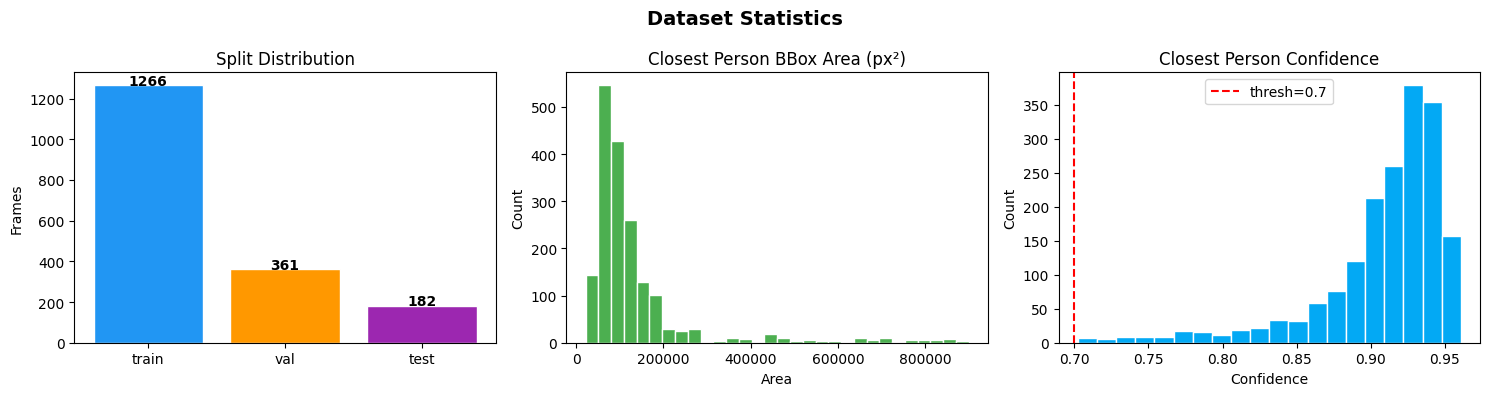

Data preparation complete. Proceed to 3.model_comparison.ipynb


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Statistics', fontsize=14, fontweight='bold')

# 1. Split distribution
split_counts = valid_df['split'].value_counts().reindex(['train', 'val', 'test'])
axes[0].bar(split_counts.index, split_counts.values,
            color=['#2196F3', '#FF9800', '#9C27B0'], edgecolor='white')
axes[0].set_title('Split Distribution')
axes[0].set_ylabel('Frames')
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 2. Closest person area distribution
axes[1].hist(valid_df['closest_area'], bins=30, color='#4CAF50', edgecolor='white')
axes[1].set_title('Closest Person BBox Area (px²)')
axes[1].set_xlabel('Area')
axes[1].set_ylabel('Count')

# 3. Detection confidence distribution
axes[2].hist(valid_df['closest_conf'], bins=20, color='#03A9F4', edgecolor='white')
axes[2].set_title('Closest Person Confidence')
axes[2].set_xlabel('Confidence')
axes[2].set_ylabel('Count')
axes[2].axvline(CONF_THRESH, color='red', linestyle='--', label=f'thresh={CONF_THRESH}')
axes[2].legend()

plt.tight_layout()
plt.show()

print('Data preparation complete. Proceed to 3.model_comparison.ipynb')